# First steps with the new code
Lets try the new Trefftzmesh

In [1]:
from trefftz.mesh import TrefftzMesh

In [2]:
from enum import IntEnum, StrEnum



class WaveguideRegionsGMSH(IntEnum):
    OMEGA = 0
    GAMMA = 1
    SIGMA_L = 2
    SIGMA_R = 3


def CleanWaveguide_GMSH(H: float = 1., R: float = 5., lc: float = 0.3, verbose: bool = False) -> TrefftzMesh[WaveguideRegionsGMSH]:
    '''Creates a domain corresponging to a waveguide without scatterers.
    It assumes the default tags for the subregions, i.e.:
    - Omega = 0
    - Gamma = 1
    - Sigma = 2
    '''
    import gmsh


    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", int(verbose))
    gmsh.model.add("Waveguide")
    p0 = gmsh.model.geo.addPoint(-R, 0., 0., lc)
    p1 = gmsh.model.geo.addPoint( R, 0., 0., lc)
    p2 = gmsh.model.geo.addPoint( R,  H, 0., lc)
    p3 = gmsh.model.geo.addPoint(-R,  H, 0., lc)

    bottom = gmsh.model.geo.addLine(p0, p1)
    right  = gmsh.model.geo.addLine(p1, p2)
    top    = gmsh.model.geo.addLine(p2, p3)
    left   = gmsh.model.geo.addLine(p3, p0)

    boundary = gmsh.model.geo.addCurveLoop([bottom, right, top, left])
    domain = gmsh.model.geo.addPlaneSurface([boundary])
    gmsh.model.geo.synchronize()

    gmsh.model.addPhysicalGroup(2, [domain], WaveguideRegionsGMSH.OMEGA, "Omega")
    gmsh.model.addPhysicalGroup(1, [bottom, top], WaveguideRegionsGMSH.GAMMA, "Gamma")
    gmsh.model.addPhysicalGroup(1, [left], WaveguideRegionsGMSH.SIGMA_L, "Sigma_L")
    gmsh.model.addPhysicalGroup(1, [right], WaveguideRegionsGMSH.SIGMA_R, "Sigma_R")
    
    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(2)
 
    mesh = TrefftzMesh.from_gmsh(gmsh.model, boundary_regions = WaveguideRegionsGMSH) #gmsh needs to be initialized for this to work
    
    gmsh.finalize()

    return mesh


class WaveguideRegionsNGSOLVE(StrEnum):
    OMEGA = "Omega"
    GAMMA = "Gamma"
    SIGMA_L = "Sigma_L"
    SIGMA_R = "Sigma_R"

def CleanWaveguide_NGSOLVE(H: float = 1., R: float = 5., lc: float = 0.3, verbosity: int = 0) -> TrefftzMesh[WaveguideRegionsNGSOLVE]:

    '''Creates a domain corresponging to a waveguide without scatterers.
    It assumes the default tags for the subregions, i.e.:
    - Omega = 0
    - Gamma = 1
    - Sigma = 2
    '''
    from netgen.geom2d import SplineGeometry
    from ngsolve import Mesh
    geo = SplineGeometry()
    p0 = geo.AddPoint(-R, 0.)
    p1 = geo.AddPoint( R, 0.)
    p2 = geo.AddPoint( R, H)
    p3 = geo.AddPoint(-R, H)
 
    bottom = geo.Append(["line", p0, p1], bc=WaveguideRegionsNGSOLVE.GAMMA)
    right  = geo.Append(["line", p1, p2], bc=WaveguideRegionsNGSOLVE.SIGMA_R)
    top    = geo.Append(["line", p2, p3], bc=WaveguideRegionsNGSOLVE.GAMMA)
    left   = geo.Append(["line", p3, p0], bc=WaveguideRegionsNGSOLVE.SIGMA_L)


    ngmesh = Mesh(geo.GenerateMesh(maxh=lc, perfstepsend=verbosity))

    
    mesh = TrefftzMesh.from_ngsolve(ngmesh, boundary_regions=WaveguideRegionsNGSOLVE)

    return mesh



In [3]:
R = 2.
H = 1. 

NGSOLVE = False

lc = 1.

if NGSOLVE:
    mesh = CleanWaveguide_NGSOLVE(R=R, H=H, verbosity=0, lc=lc)
    WaveguideRegions = WaveguideRegionsNGSOLVE
else:
    mesh = CleanWaveguide_GMSH(R=R, H=H, verbose=True, lc=lc)
    WaveguideRegions = WaveguideRegionsGMSH


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.00976723s, CPU 0.002833s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.000349628s, CPU 0s)
Info    : 14 nodes 30 elements


In [4]:
# from trefftz.mesh.checking_utilities import explore_edges
# import matplotlib
# matplotlib.use("TkAgg")
# print(matplotlib.get_backend())

In [5]:
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots()

In [6]:
# explore_edges(mesh,figax=(fig, ax))

In [7]:
from problems.base2 import Problem

In [8]:
from trefftz.dg.basis import LinearlySpacedBasis

k = 8.0

basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=15)

In [9]:
from trefftz.dg.boundary_conditions2 import SoundHardBC, NtDBC

In [10]:
boundary_conditions = {WaveguideRegions.GAMMA: SoundHardBC(),
                       WaveguideRegions.SIGMA_L: NtDBC(truncating_radius=R, data=1.),
                       WaveguideRegions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

In [11]:
from trefftz.dg.assemblers import SerialNumerics

In [12]:
from trefftz.dg.serial_kernels import SoundHardKernel, UltraWeakKernel, NtDLocal, WaveguideNtD_nonlocal

In [13]:
serial_numerics = SerialNumerics(interior_kernel=UltraWeakKernel(a=0.5, b=0.5),
                                 local_boundary_kernels={SoundHardBC: SoundHardKernel(d_1 = 0.5),
                                                         NtDBC: NtDLocal(R=R, d_2=0.5, H=H, n=2)},
                                 nonlocal_boundary_kernels={NtDBC: WaveguideNtD_nonlocal(R=R, d_2=0.5, M = 20, H = 1.)})

In [14]:
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=None, numerics=serial_numerics)

In [15]:
A = P.assemble_LHS()

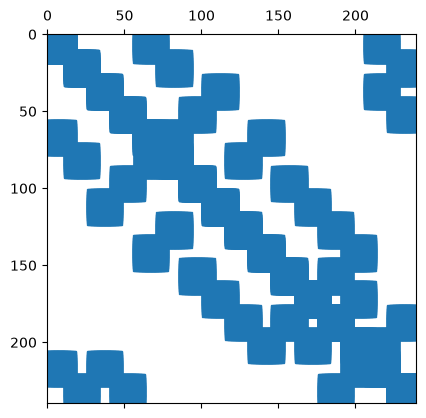

In [16]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [17]:
b = P.assemble_RHS()

In [18]:
P.solve()

In [19]:
P.u_h.coefficients.reshape((-1,3))

array([[-2.39393710e-02-0.10712241j,  3.28052758e-03+0.11789358j,
         4.78860476e-01-0.15383875j],
       [-3.31416423e-02+0.09540827j,  4.42945811e-02+0.08463136j,
         3.61186737e-01+0.08631658j],
       [-1.60034164e-01+0.22510195j,  1.53879013e-01+0.07847979j,
        -5.39182318e-02-0.16785974j],
       [ 7.35687868e-02+0.27824126j,  2.71965945e-01+0.2157305j ,
        -4.30455739e-02+0.01889696j],
       [ 1.74723457e-02+0.0246819j ,  5.28810496e-01-0.10061326j,
        -4.40427584e-02+0.12243749j],
       [-2.06180006e-02+0.01225681j,  1.35141814e-02+0.02318833j,
         3.84956688e-01+0.21379846j],
       [-1.05414234e-01-0.08895306j,  2.92080213e-02-0.12262417j,
         2.35071233e-01+0.33229904j],
       [ 4.52545362e-02+0.22836122j,  1.20832753e-01-0.02355544j,
         7.94925385e-02-0.09518648j],
       [ 1.19194395e-01-0.20437689j, -1.49889374e-01+0.36941737j,
         3.08709385e-02+0.10783679j],
       [ 1.11010514e-01-0.03775376j,  4.68061226e-01-0.0220235j 

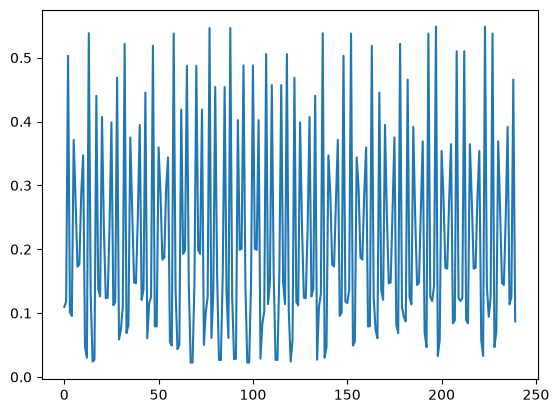

In [20]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [21]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(np.float64(-2.0100502512562812),
 np.float64(2.0100502512562812),
 np.float64(-0.005050505050505051),
 np.float64(1.005050505050505))

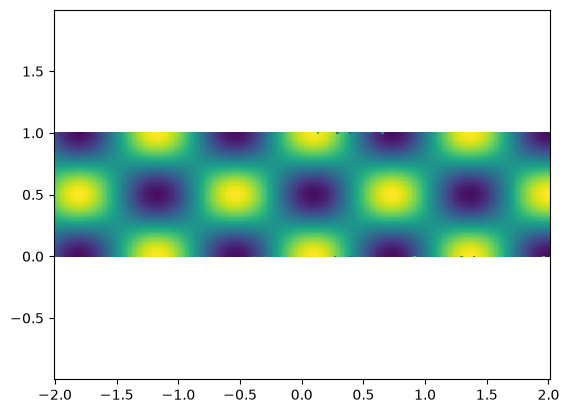

In [22]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real)
plt.axis('equal')